In [17]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RANSACRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint
from sklearn.ensemble import IsolationForest, ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [18]:

# Carregando o Dataset
url = 'https://raw.githubusercontent.com/klaytoncastro/idp-storytelling/master/airquality/airquality.csv'
df = pd.read_csv(url, delimiter = ';', decimal = ',')
df.head()

# Verificando a estrutura de dados
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1 MB


In [19]:

# Convertendo as colunas Date e Time para DateTime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

# Removendo as colunas originais Date e Time
df.drop(columns=['Date', 'Time'], inplace=True)
df.head()

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         9357 non-null   float64       
 1   PT08.S1(CO)    9357 non-null   int64         
 2   NMHC(GT)       9357 non-null   int64         
 3   C6H6(GT)       9357 non-null   float64       
 4   PT08.S2(NMHC)  9357 non-null   int64         
 5   NOx(GT)        9357 non-null   int64         
 6   PT08.S3(NOx)   9357 non-null   int64         
 7   NO2(GT)        9357 non-null   int64         
 8   PT08.S4(NO2)   9357 non-null   int64         
 9   PT08.S5(O3)    9357 non-null   int64         
 10  T              9357 non-null   float64       
 11  RH             9357 non-null   float64       
 12  AH             9357 non-null   float64       
 13  DateTime       9357 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(5), int64(8)
memory usage: 1023.6 KB


In [20]:

# Calculando as correlações entre as variáveis ​​preditoras e a variável alvo
correlations = df.corr()['CO(GT)'].sort_values(ascending=False)
print(correlations)

# Verificando a distribuição dos dados
df.describe()


CO(GT)           1.000000
NO2(GT)          0.671127
NOx(GT)          0.526451
DateTime         0.136673
NMHC(GT)         0.128351
PT08.S5(O3)      0.080310
PT08.S1(CO)      0.041411
PT08.S2(NMHC)    0.029926
C6H6(GT)        -0.031378
AH              -0.045892
RH              -0.048227
T               -0.068939
PT08.S4(NO2)    -0.073724
PT08.S3(NOx)    -0.089981
Name: CO(GT), dtype: float64


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,2004-09-21 16:00:00
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,2004-03-10 18:00:00
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,2004-06-16 05:00:00
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,2004-09-21 16:00:00
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN


In [21]:

# Identificamos um padrão estranho, onde -200 aparece como valor mínimo para cada uma das variáveis.
# Por isso, vamos contar valores -200 em cada coluna e avaliar se isso é frequente ou eventual.
print("Contagem de valores -200 em cada coluna:")
for column in df.columns:
    count_negative_200 = (df[column] == -200).sum()
    print(f"{column}: {count_negative_200}")

# De fato, são valores anômalos. Vamos substituir -200 por NaN (NULL)
df.replace(-200, np.nan, inplace=True)
df.describe()


Contagem de valores -200 em cada coluna:
CO(GT): 1683
PT08.S1(CO): 366
NMHC(GT): 8443
C6H6(GT): 366
PT08.S2(NMHC): 366
NOx(GT): 1639
PT08.S3(NOx): 366
NO2(GT): 1642
PT08.S4(NO2): 366
PT08.S5(O3): 366
T: 366
RH: 366
AH: 366
DateTime: 0


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN


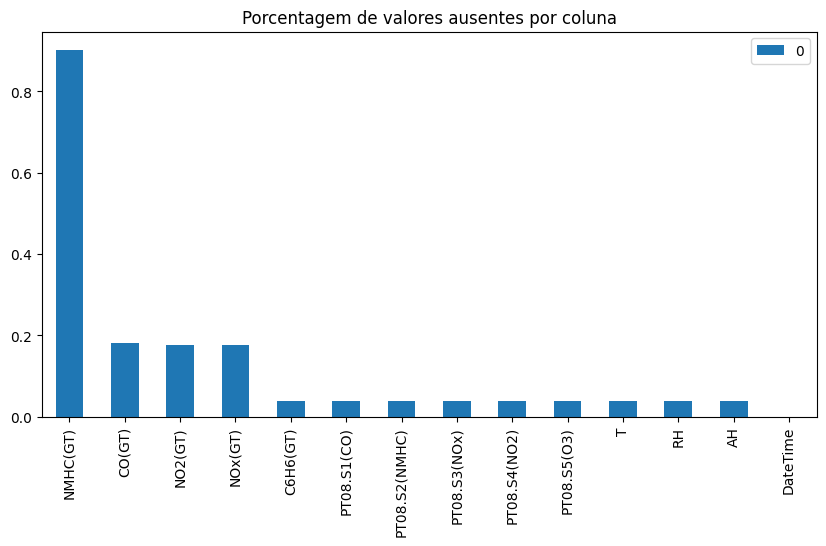

In [22]:

# Verificando quantidade de missing values por coluna
missing_values = df.isna().sum().div(df.shape[0]).to_frame().sort_values(by=0, ascending=False)
missing_values.plot(kind='bar', figsize=(10, 5))
plt.title('Porcentagem de valores ausentes por coluna')
plt.show()


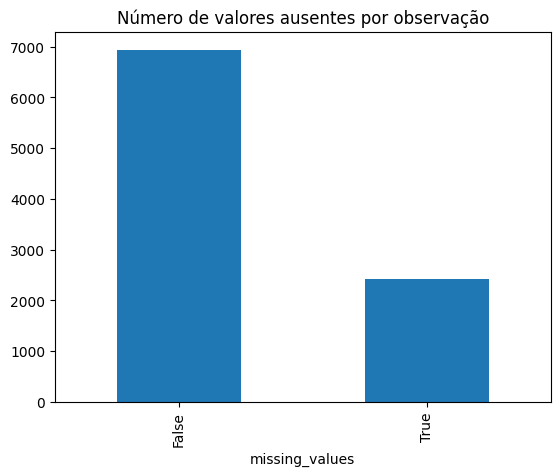

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime,missing_values
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,False
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,False
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,False
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,False
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,False


In [23]:

# Decidimos a descartar a coluna NMHC(GT), mais 80% de valores ausentes. Imputar a mediana pode apresentar padrões lineares artificiais.
df.drop(columns=['NMHC(GT)'], inplace=True)
df.describe()

# Criando uma nova coluna para agregar os valores e gerando um gráfico de barras dos total de valores ausentes por registro único
df['missing_values'] = df.isnull().any(axis=1)
df.groupby('missing_values').size().plot(kind='bar')
plt.title('Número de valores ausentes por observação')
plt.show()

df.head()


In [24]:

# Hipótese 1: se descartarmos as demais colunas ou registros com valores nulos, perderemos muita capacidade de previsão do modelo.
# Poderiamos preencher os valores NaN com a mediana da coluna, mas os padrões lineares gerados seriam de fato artificiais.
# Dessa forma, vamos seguir com a Hipótese 2.
'''
for column in df.columns:
    if df[column].isnull().any():
        df[column].fillna(df[column].median(), inplace=True)

df.describe()
'''

# Hipótese 2: Como ainda teremos em torno de 7000 observações na amostra após remover os dados ausentes, decidimos removê-los para assegurar maior fidelidade.
df = df.dropna()
df.describe()


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941
mean,2.182467,1119.913269,10.554488,958.543005,250.671949,816.893387,113.874082,1452.648898,1057.756519,17.755323,48.881905,0.985573,2004-09-28 01:45:40.066272
min,0.100000,647.000000,0.200000,390.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,956.000000,4.900000,760.000000,103.000000,642.000000,79.000000,1207.000000,760.000000,11.200000,35.300000,0.694100,2004-06-15 05:00:00
50%,1.900000,1085.000000,8.800000,931.000000,186.000000,786.000000,110.000000,1457.000000,1006.000000,16.800000,49.200000,0.953900,2004-10-08 05:00:00
75%,2.900000,1254.000000,14.600000,1135.000000,335.000000,947.000000,142.000000,1683.000000,1322.000000,23.700000,62.200000,1.251600,2005-01-12 18:00:00
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,333.000000,2775.000000,2523.000000,44.600000,88.700000,2.180600,2005-04-04 14:00:00
std,1.441158,218.733754,7.465226,264.055002,208.611371,251.897200,47.475017,353.301576,406.509957,8.844909,17.433193,0.401097,NaN


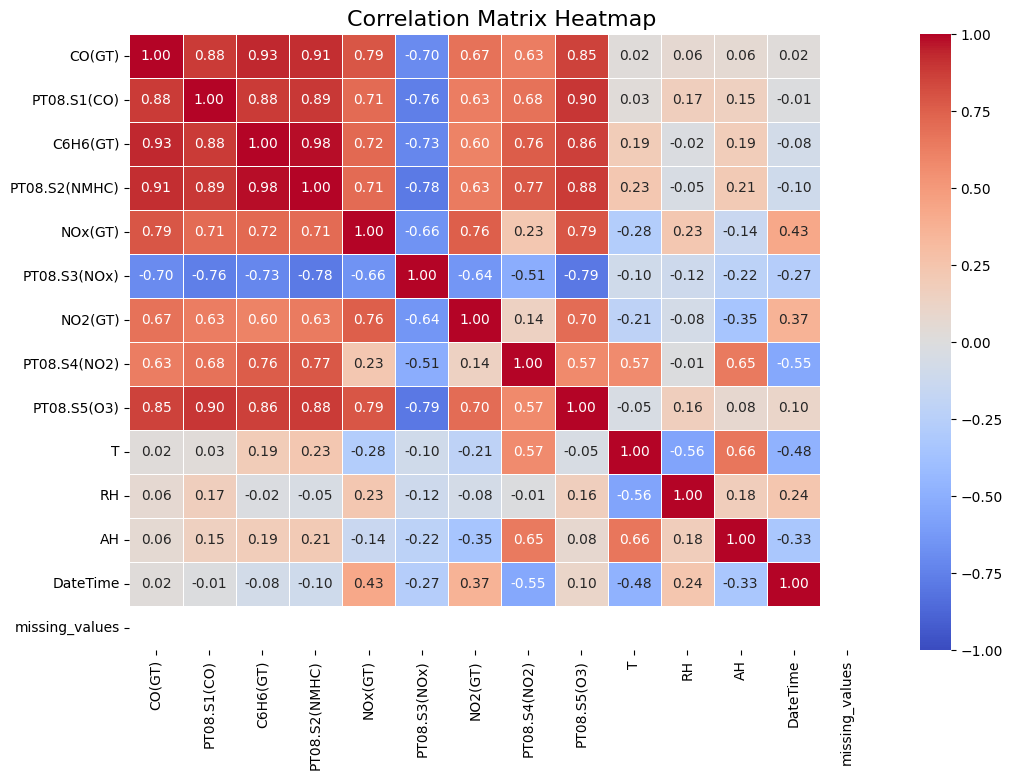

In [25]:

# As distribuições parecem melhores agora. Vamos exibir a nova matriz de correlação para análise.

correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin = -1)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()


In [26]:

# Vamos excluir a coluna intermediária 'missing_values' e a coluna 'DateTime'
df.drop(columns=['DateTime'], inplace=True)
df.drop(columns=['missing_values'], inplace=True)

# Vamos manter as demais variáveis de baixa correlação por enquanto.
df.drop(columns=['T'], inplace=True)
df.drop(columns=['RH'], inplace=True)
df.drop(columns=['AH'], inplace=True)

df.head()


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0


In [27]:

# Calculando as correlações entre as variáveis ​​preditoras e a variável alvo
correlations = df.corr()['CO(GT)'].sort_values(ascending=False)
print(correlations)

# Preparando as variáveis para treinar o modelo.
X = df.drop('CO(GT)', axis=1)
y = df['CO(GT)']


CO(GT)           1.000000
C6H6(GT)         0.930008
PT08.S2(NMHC)    0.914310
PT08.S1(CO)      0.877014
PT08.S5(O3)      0.853480
NOx(GT)          0.786456
NO2(GT)          0.673840
PT08.S4(NO2)     0.630834
PT08.S3(NOx)    -0.701038
Name: CO(GT), dtype: float64


In [135]:
split_idx = int(len(X) * 0.97)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTreino: {X_train.index[0]} → {X_train.index[-1]} ({len(X_train)} amostras)")
print(f"Teste:  {X_test.index[0]}  → {X_test.index[-1]}  ({len(X_test)} amostras)")

# Treinar com o ExtraTrees
model = ExtraTreesRegressor(random_state=7, n_estimators=67, max_features='sqrt', max_depth=100, min_samples_split=13, min_samples_leaf=3, bootstrap = True, oob_score=True)
#model = ExtraTreesRegressor(random_state=42, n_estimators=350, max_features='sqrt', max_depth=None, min_samples_split=2, min_samples_leaf=1)
#model = ExtraTreesRegressor();
model.fit(X_train, y_train)



Treino: 0 → 9144 (6732 amostras)
Teste:  9145  → 9356  (209 amostras)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",67
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",13
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is th

In [136]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fazer previsões
y_pred = model.predict(X_test)

# Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Métricas no conjunto de teste ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"OOB Score: {model.oob_score_:.4f}")

df.describe()



=== Métricas no conjunto de teste ===
MAE  : 0.1646
MSE  : 0.0536
RMSE : 0.2315
R²   : 0.9384
OOB Score: 0.9104


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
count,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000,6941.000000
mean,2.182467,1119.913269,10.554488,958.543005,250.671949,816.893387,113.874082,1452.648898,1057.756519
std,1.441158,218.733754,7.465226,264.055002,208.611371,251.897200,47.475017,353.301576,406.509957
min,0.100000,647.000000,0.200000,390.000000,2.000000,322.000000,2.000000,551.000000,221.000000
25%,1.100000,956.000000,4.900000,760.000000,103.000000,642.000000,79.000000,1207.000000,760.000000
50%,1.900000,1085.000000,8.800000,931.000000,186.000000,786.000000,110.000000,1457.000000,1006.000000
75%,2.900000,1254.000000,14.600000,1135.000000,335.000000,947.000000,142.000000,1683.000000,1322.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,333.000000,2775.000000,2523.000000


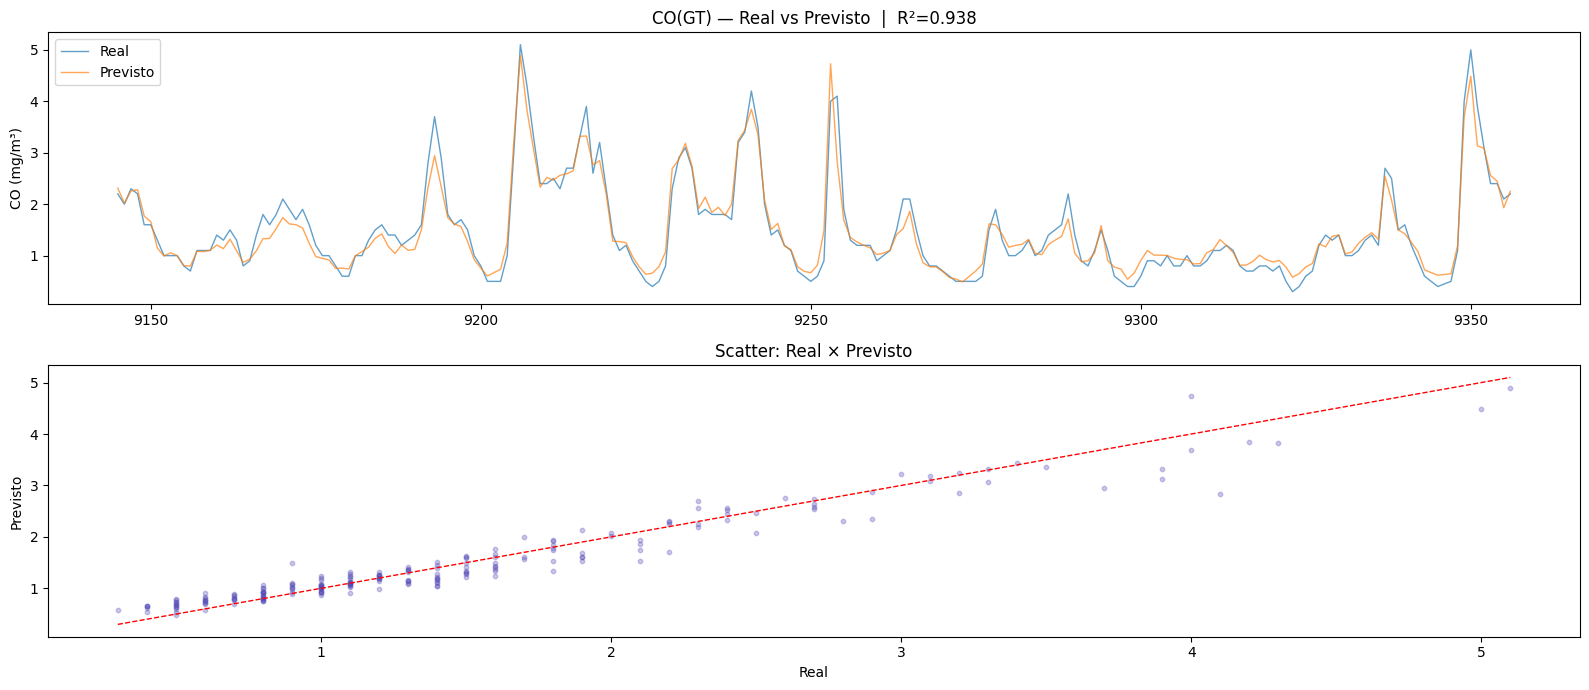

In [137]:

# Gráfico de valores previstos x valores atuais
fig, axes = plt.subplots(2, 1, figsize=(16, 7))

axes[0].plot(y_test.index, y_test.values,  label="Real",   alpha=0.7, linewidth=1)
axes[0].plot(y_test.index, y_pred,          label="Previsto", alpha=0.7, linewidth=1)
axes[0].set_title(f"CO(GT) — Real vs Previsto  |  R²={r2:.3f}")
axes[0].set_ylabel("CO (mg/m³)")
axes[0].legend()

axes[1].scatter(y_test, y_pred, alpha=0.3, s=10, color="#534AB7")
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lim, lim, "r--", linewidth=1)
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Previsto")
axes[1].set_title("Scatter: Real × Previsto")

plt.tight_layout()
plt.show()

In [138]:
from joblib import dump

dump(model, "../models/modelo2.pkl")

['../models/modelo2.pkl']